In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.cluster import KMeans
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.metrics import silhouette_score

In [2]:
df_severity = pd.read_csv("data/severity.csv")

In [3]:
df_frequency = pd.read_csv("data/frequency.csv")

In [4]:
df_severity.head()

,uwYear,gender,carType,carCat,job,age,nYears,carVal,cover,density,claimSizeMD
0,2009,Female,A,Medium,Housewife,41,0,24940,1,273,740
1,2009,Male,B,Small,Unemployed,25,12,48945,0,190,207
2,2009,Female,E,Small,Employed,29,7,1525,0,225,803
3,2009,Male,A,Small,Self-employed,47,12,18480,1,129,868
4,2009,Female,C,Large,Employed,47,7,8690,0,290,1746


In [5]:
df_severity.shape

(12256, 11)

In [6]:
df_severity.isna().any().sum()

np.int64(0)

Okay, there are no missing values in the data. So it's a good sign at least :)

In [7]:
df_severity.duplicated().any()

np.False_

and no duplicates :))

In [8]:
df_severity.info()

<class 'pandas.DataFrame'>
RangeIndex: 12256 entries, 0 to 12255
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   uwYear       12256 non-null  int64
 1   gender       12256 non-null  str  
 2   carType      12256 non-null  str  
 3   carCat       12256 non-null  str  
 4   job          12256 non-null  str  
 5   age          12256 non-null  int64
 6   nYears       12256 non-null  int64
 7   carVal       12256 non-null  int64
 8   cover        12256 non-null  int64
 9   density      12256 non-null  int64
 10  claimSizeMD  12256 non-null  int64
dtypes: int64(7), str(4)
memory usage: 1.3 MB


In [9]:
convert_dtype_dict = {
    "gender": "category",
    "carType": "category",
    "carCat": "category",
    "job": "category",
}

In [10]:
df_severity = df_severity.astype(convert_dtype_dict)

In [11]:
df_severity.dtypes

uwYear            int64
gender         category
carType        category
carCat         category
job            category
age               int64
nYears            int64
carVal            int64
cover             int64
density           int64
claimSizeMD       int64
dtype: object

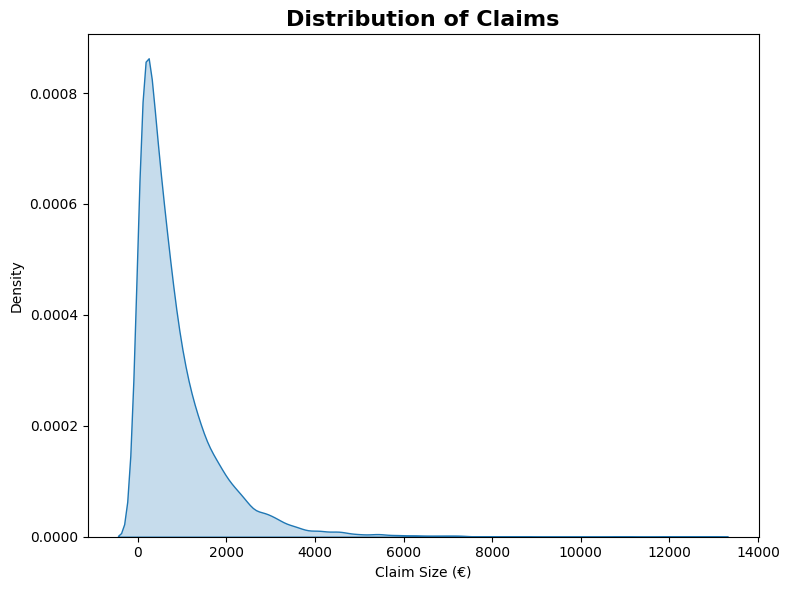

In [12]:
fig, ax = plt.subplots(figsize=(8, 6))

sns.kdeplot(data=df_severity, ax=ax, x="claimSizeMD", fill=True)
ax.set_title("Distribution of Claims", fontweight="bold", fontsize=16)
ax.set(xlabel="Claim Size (€)")

fig.tight_layout()

the distribution of claim sizes is right-skewed. so let's see how does a log transform of them make it. but for the statistical tests it is better to use a non-parametric test.

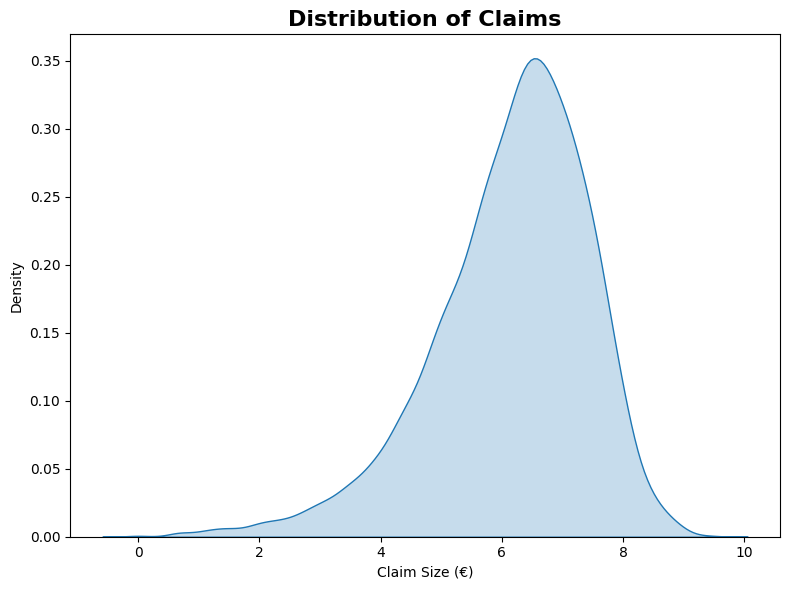

In [13]:
log_claim_size = np.log1p(df_severity["claimSizeMD"])

fig, ax = plt.subplots(figsize=(8, 6))

sns.kdeplot(ax=ax, x=log_claim_size, fill=True)
ax.set_title("Distribution of Claims", fontweight="bold", fontsize=16)
ax.set(xlabel="Claim Size (€)")

fig.tight_layout()

so yeah the log transform makes it kinda normally distributed. maybe we can use this fact in the model building process.

In [14]:
df_frequency.head()

,uwYear,gender,carType,carCat,job,age,nYears,carVal,cover,density,claimNumbMD
0,2009,Male,C,Large,Employed,25,3,15080,0,72.012883,1
1,2009,Male,E,Large,Employed,20,2,22370,1,39.550411,1
2,2009,Female,E,Large,Unemployed,42,0,39650,0,169.529148,1
3,2009,Female,C,Medium,Housewife,21,0,12600,1,58.894688,1
4,2009,Female,D,Large,Employed,33,10,9065,0,109.631885,1


In [15]:
df_frequency.shape

(24774, 11)

In [16]:
df_frequency.isna().any().sum()

np.int64(0)

In [17]:
df_frequency[df_frequency.duplicated(keep=False)].sort_values(
    by=list(df_frequency.columns)
)

,uwYear,gender,carType,carCat,job,age,nYears,carVal,cover,density,claimNumbMD
11,2009,Female,A,Large,Housewife,65,15,11880,0,223.308572,1
46,2009,Female,A,Large,Housewife,65,15,11880,0,223.308572,1
12,2009,Female,A,Medium,Unemployed,25,2,23130,0,107.817053,1
47,2009,Female,A,Medium,Unemployed,25,2,23130,0,107.817053,1
15,2009,Female,A,Small,Employed,29,0,11370,0,32.212556,1
50,2009,Female,A,Small,Employed,29,0,11370,0,32.212556,1
7,2009,Female,B,Medium,Employed,29,12,8965,0,272.966995,1
42,2009,Female,B,Medium,Employed,29,12,8965,0,272.966995,1
3,2009,Female,C,Medium,Housewife,21,0,12600,1,58.894688,1
38,2009,Female,C,Medium,Housewife,21,0,12600,1,58.894688,1


so there are these duplicates, and even though we don't have a unique identifier, I think it's safe to drop them because it is highly unlikely to have these very similar rows.

In [18]:
df_frequency.drop_duplicates(inplace=True)

In [19]:
df_frequency.info()

<class 'pandas.DataFrame'>
Index: 24753 entries, 0 to 24773
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   uwYear       24753 non-null  int64  
 1   gender       24753 non-null  str    
 2   carType      24753 non-null  str    
 3   carCat       24753 non-null  str    
 4   job          24753 non-null  str    
 5   age          24753 non-null  int64  
 6   nYears       24753 non-null  int64  
 7   carVal       24753 non-null  int64  
 8   cover        24753 non-null  int64  
 9   density      24753 non-null  float64
 10  claimNumbMD  24753 non-null  int64  
dtypes: float64(1), int64(6), str(4)
memory usage: 2.8 MB


In [20]:
df_frequency = df_frequency.astype(convert_dtype_dict)

In [21]:
df_frequency.dtypes

uwYear            int64
gender         category
carType        category
carCat         category
job            category
age               int64
nYears            int64
carVal            int64
cover             int64
density         float64
claimNumbMD       int64
dtype: object

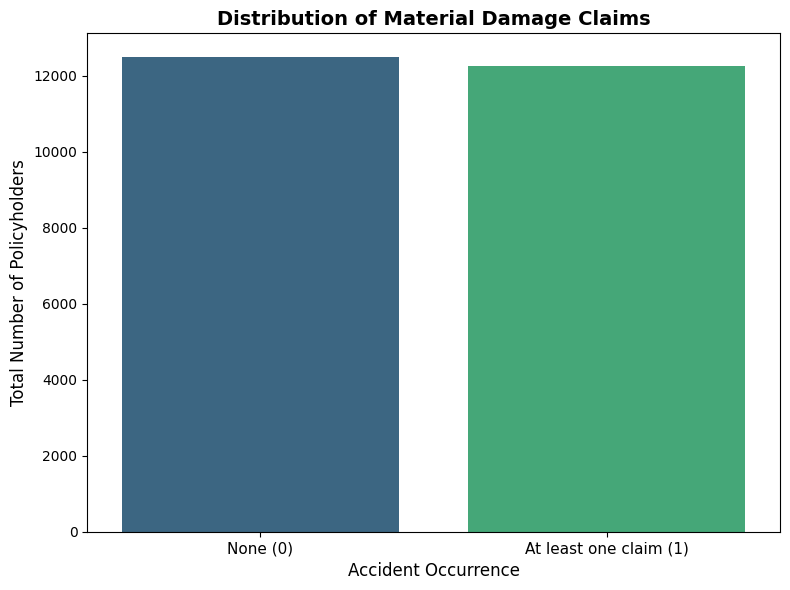

In [22]:
fig, ax = plt.subplots(figsize=(8, 6))

sns.countplot(
    data=df_frequency,
    ax=ax,
    x="claimNumbMD",
    hue="claimNumbMD",
    palette="viridis",
    legend=False,
)
ax.set_xticks([0, 1])
ax.set_xticklabels(["None (0)", "At least one claim (1)"], fontsize=11)

ax.set_title("Distribution of Material Damage Claims", fontweight="bold", fontsize=14)
ax.set_xlabel("Accident Occurrence", fontsize=12)
ax.set_ylabel("Total Number of Policyholders", fontsize=12)

fig.tight_layout()

## Exploring `gender`

In [23]:
df_severity["gender"].value_counts()

gender
Male      8343
Female    3913
Name: count, dtype: int64

In [24]:
df_severity.groupby("gender")["claimSizeMD"].mean().round(decimals=2)

gender
Female    792.46
Male      900.73
Name: claimSizeMD, dtype: float64

In [25]:
df_severity.groupby("gender")["claimSizeMD"].median()

gender
Female    508.0
Male      581.0
Name: claimSizeMD, dtype: float64

so men tend to have a larger claim size. but let's run a statistical test to see if it's actually significant.

In [26]:
female_claims = df_severity[df_severity["gender"] == "Female"]["claimSizeMD"]
male_claims = df_severity[df_severity["gender"] == "Male"]["claimSizeMD"]

In [27]:
u_stat, p_value = stats.mannwhitneyu(male_claims, female_claims)

In [28]:
print(f"Mann-Whitney U statistic: {u_stat:.2f}")
print(f"p-value: {p_value:.4f}")

Mann-Whitney U statistic: 17455144.50
p-value: 0.0000


so it's statistically significant that men make higher claim sizes.

In [29]:
df_frequency["gender"].value_counts()

gender
Male      16289
Female     8464
Name: count, dtype: int64

the men make claims twice as much as women. and it's consistent with the result we got from the severity data set

In [30]:
df_frequency.groupby("gender")["claimNumbMD"].value_counts().reset_index()

,gender,claimNumbMD,count
0,Female,0,4551
1,Female,1,3913
2,Male,1,8343
3,Male,0,7946


In [31]:
prop_df = (
    df_frequency.groupby("gender")["claimNumbMD"]
    .value_counts(normalize=True)
    .reset_index(name="proportion")
)
prop_df

,gender,claimNumbMD,proportion
0,Female,0,0.537689
1,Female,1,0.462311
2,Male,1,0.512186
3,Male,0,0.487814


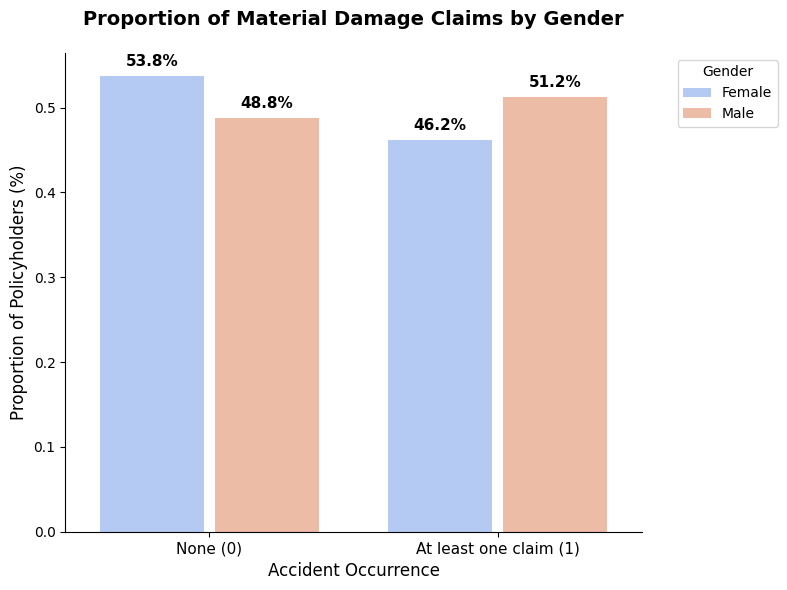

In [32]:
fig, ax = plt.subplots(figsize=(8, 6))

sns.barplot(
    data=prop_df,
    ax=ax,
    x="claimNumbMD",
    y="proportion",
    hue="gender",
    palette="coolwarm",
    gap=0.1,
)
ax.set_xticks([0, 1])
ax.set_xticklabels(["None (0)", "At least one claim (1)"], fontsize=11)

ax.set_title(
    "Proportion of Material Damage Claims by Gender",
    fontweight="bold",
    fontsize=14,
    pad=20,
)
ax.set_xlabel("Accident Occurrence", fontsize=12)
ax.set_ylabel("Proportion of Policyholders (%)", fontsize=12)

ax.legend(title="Gender", bbox_to_anchor=(1.05, 1), loc="upper left")

for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(
            f"{height * 100:.1f}%",
            (p.get_x() + p.get_width() / 2.0, height),
            ha="center",
            va="bottom",
            fontsize=11,
            fontweight="bold",
            xytext=(0, 5),
            textcoords="offset points",
        )

sns.despine()
fig.tight_layout()

So now I'm gonna run a chi-square test of independence to see if the difference of frequency claims between men and women, as shown in the plot, is significant

In [33]:
contingency_gender = pd.crosstab(df_frequency["gender"], df_frequency["claimNumbMD"])
contingency_gender

claimNumbMD,0,1
gender,,
Female,4551,3913
Male,7946,8343


In [34]:
chi2_statistic, p_value, dof, excepted = stats.chi2_contingency(contingency_gender)

In [35]:
print(f"Chi-Square Statistic: {chi2_statistic:.2f}")
print(f"P-value: {p_value:.4e}")

alpha = 0.05
if p_value < alpha:
    print("Significant")
else:
    print("Not significant")

Chi-Square Statistic: 55.23
P-value: 1.0741e-13
Significant


so men are more likely to make a claim, and the men's claims are larger in amount. so `gender` should definitely be considered in profiling

## Exploring `carType`

In [36]:
df_severity["carType"].value_counts()

carType
A    2999
D    2597
B    2547
E    2400
C    1713
Name: count, dtype: int64

In [37]:
df_severity.groupby("carType")["claimSizeMD"].mean().round(decimals=2).sort_values(
    ascending=False
)

carType
A    963.93
B    926.17
C    846.78
D    785.61
E    781.31
Name: claimSizeMD, dtype: float64

In [38]:
df_severity.groupby("carType")["claimSizeMD"].median().sort_values(ascending=False)

carType
A    630.0
B    605.0
C    543.0
D    510.0
E    509.5
Name: claimSizeMD, dtype: float64

In [39]:
claims_A = df_severity[df_severity["carType"] == "A"]["claimSizeMD"]
claims_B = df_severity[df_severity["carType"] == "B"]["claimSizeMD"]
claims_C = df_severity[df_severity["carType"] == "C"]["claimSizeMD"]
claims_D = df_severity[df_severity["carType"] == "D"]["claimSizeMD"]
claims_E = df_severity[df_severity["carType"] == "E"]["claimSizeMD"]

In [40]:
h_statistic, p_value = stats.kruskal(claims_A, claims_B, claims_C, claims_D, claims_D)

print(f"Kruskal-Wallis H-statistic: {h_statistic:.2f}")
print(f"P-value: {p_value:.4e}")

if p_value < 0.05:
    print("Significant")
else:
    print("Non-significant")

Kruskal-Wallis H-statistic: 70.82
P-value: 1.5207e-14
Significant


so there is at least one type of car that has higher claim sizes than the rest

In [41]:
prop_df_carType = (
    df_frequency.groupby("carType")["claimNumbMD"]
    .value_counts(normalize=True)
    .reset_index(name="proportion")
)
prop_df_carType

,carType,claimNumbMD,proportion
0,A,0,0.540805
1,A,1,0.459195
2,B,0,0.517888
3,B,1,0.482112
4,C,0,0.505770
5,C,1,0.494230
6,D,1,0.511825
7,D,0,0.488175
8,E,1,0.545579
9,E,0,0.454421


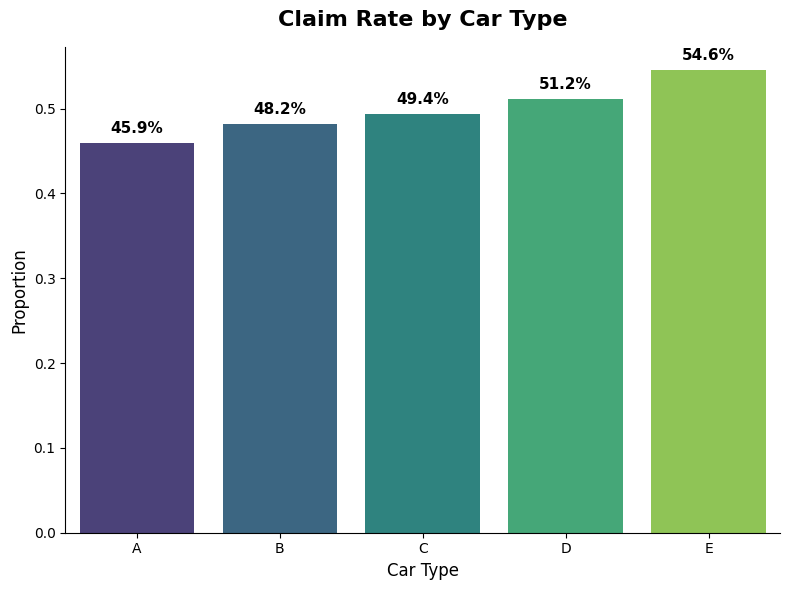

In [42]:
fig, ax = plt.subplots(figsize=(8, 6))

sns.barplot(
    data=df_frequency,
    ax=ax,
    x="carType",
    y="claimNumbMD",
    hue="carType",
    legend=False,
    palette="viridis",
    order=["A", "B", "C", "D", "E"],
    errorbar=None,
    dodge=False,
)

for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(
            f"{height * 100:.1f}%",
            (p.get_x() + p.get_width() / 2.0, height),
            ha="center",
            va="bottom",
            fontsize=11,
            fontweight="bold",
            xytext=(0, 5),
            textcoords="offset points",
        )

ax.set_title("Claim Rate by Car Type", fontweight="bold", fontsize=16, pad=15)
ax.set_xlabel("Car Type", fontsize=12)
ax.set_ylabel("Proportion", fontsize=12)

sns.despine()
fig.tight_layout()

In [43]:
contingency_carType = pd.crosstab(df_frequency["carType"], df_frequency["claimNumbMD"])
contingency_carType

claimNumbMD,0,1
carType,,
A,3532,2999
B,2736,2547
C,1753,1713
D,2477,2597
E,1999,2400


In [44]:
chi2_statistic, p_value, dof, expected = stats.chi2_contingency(contingency_carType)

print(f"Chi-Square Statistic: {chi2_statistic:.2f}")
print(f"P-value: {p_value:.4e}")

alpha = 0.05
if p_value < alpha:
    print("Significant")
else:
    print("Non-significant")

Chi-Square Statistic: 87.78
P-value: 3.9076e-18
Significant


so the `carType` also has significant effect. both in severity and frequency of the claims

## Exploring `carCat`

In [45]:
df_severity["carCat"].value_counts()

carCat
Medium    4515
Small     4168
Large     3573
Name: count, dtype: int64

In [46]:
df_severity.groupby("carCat")["claimSizeMD"].mean().round(decimals=2).sort_values(
    ascending=False
)

carCat
Small     901.82
Medium    864.13
Large     827.15
Name: claimSizeMD, dtype: float64

In [47]:
df_severity.groupby("carCat")["claimSizeMD"].median().sort_values(ascending=False)

carCat
Small     574.0
Medium    571.0
Large     534.0
Name: claimSizeMD, dtype: float64

In [48]:
claims_small = df_severity[df_severity["carCat"] == "Small"]["claimSizeMD"]
claims_medium = df_severity[df_severity["carCat"] == "Medium"]["claimSizeMD"]
claims_large = df_severity[df_severity["carCat"] == "Large"]["claimSizeMD"]

In [49]:
h_statistic, p_value = stats.kruskal(claims_small, claims_medium, claims_large)

print(f"Kruskal-Wallis H-statistic: {h_statistic:.2f}")
print(f"P-value: {p_value:.4e}")
print("Significant" if p_value < 0.05 else "Non-significant")

Kruskal-Wallis H-statistic: 10.35
P-value: 5.6672e-03
Significant


so the size of the car does have an effect on the severity of the claim

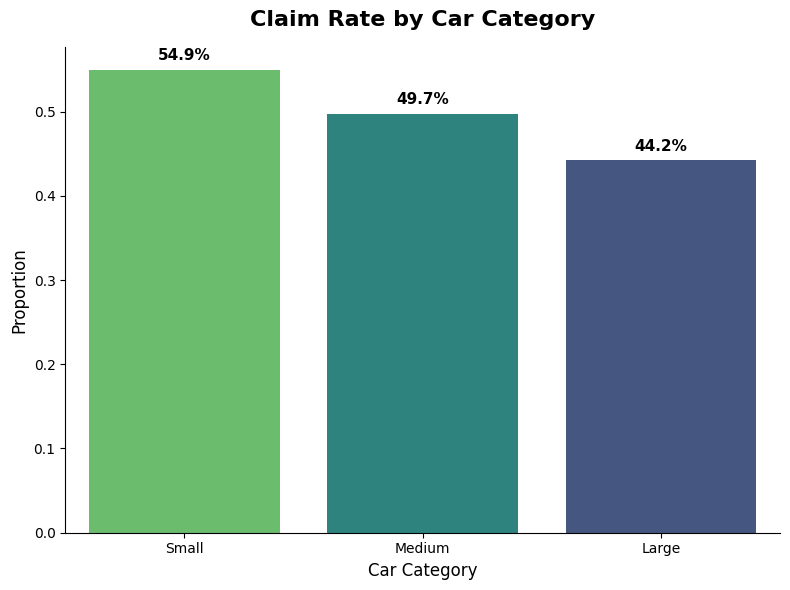

In [50]:
fig, ax = plt.subplots(figsize=(8, 6))

sns.barplot(
    data=df_frequency,
    ax=ax,
    x="carCat",
    y="claimNumbMD",
    hue="carCat",
    legend=False,
    palette="viridis",
    order=["Small", "Medium", "Large"],
    errorbar=None,
    dodge=False,
)

for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(
            f"{height * 100:.1f}%",
            (p.get_x() + p.get_width() / 2.0, height),
            ha="center",
            va="bottom",
            fontsize=11,
            fontweight="bold",
            xytext=(0, 5),
            textcoords="offset points",
        )

ax.set_title("Claim Rate by Car Category", fontweight="bold", fontsize=16, pad=15)
ax.set_xlabel("Car Category", fontsize=12)
ax.set_ylabel("Proportion", fontsize=12)
sns.despine()
fig.tight_layout()

In [51]:
contingency_carCat = pd.crosstab(df_frequency["carCat"], df_frequency["claimNumbMD"])
contingency_carCat

claimNumbMD,0,1
carCat,,
Large,4511,3573
Medium,4568,4515
Small,3418,4168


In [52]:
chi2_statistic, p_value, dof, expected = stats.chi2_contingency(contingency_carCat)

print(f"Chi-Square Statistic: {chi2_statistic:.2f}")
print(f"P-value: {p_value:.4e}")
print("Significant" if p_value < 0.05 else "Non-significant")

Chi-Square Statistic: 180.97
P-value: 5.0515e-40
Significant


the variable `carCat` does have a significant effect in both claim size and frequency

## Exploring `job`

In [53]:
df_severity["job"].value_counts()

job
Employed         4295
Housewife        2920
Unemployed       2489
Self-employed    2088
Retired           464
Name: count, dtype: int64

In [54]:
df_severity.groupby("job")["claimSizeMD"].mean().round(decimals=2).sort_values(
    ascending=False
)

job
Unemployed       1093.33
Retired          1071.63
Employed          846.64
Self-employed     830.65
Housewife         694.00
Name: claimSizeMD, dtype: float64

In [55]:
df_severity.groupby("job")["claimSizeMD"].median().sort_values(ascending=False)

job
Retired          760.0
Unemployed       695.0
Self-employed    561.0
Employed         550.0
Housewife        458.5
Name: claimSizeMD, dtype: float64

In [56]:
job_groups = [
    df_severity[df_severity["job"] == j]["claimSizeMD"]
    for j in df_severity["job"].unique()
]

In [57]:
h_statistic, p_value = stats.kruskal(*job_groups)

print(f"Kruskal-Wallis H-statistic: {h_statistic:.2f}")
print(f"P-value: {p_value:.4e}")
print("Significant" if p_value < 0.05 else "Non-significant")

Kruskal-Wallis H-statistic: 201.93
P-value: 1.4445e-42
Significant


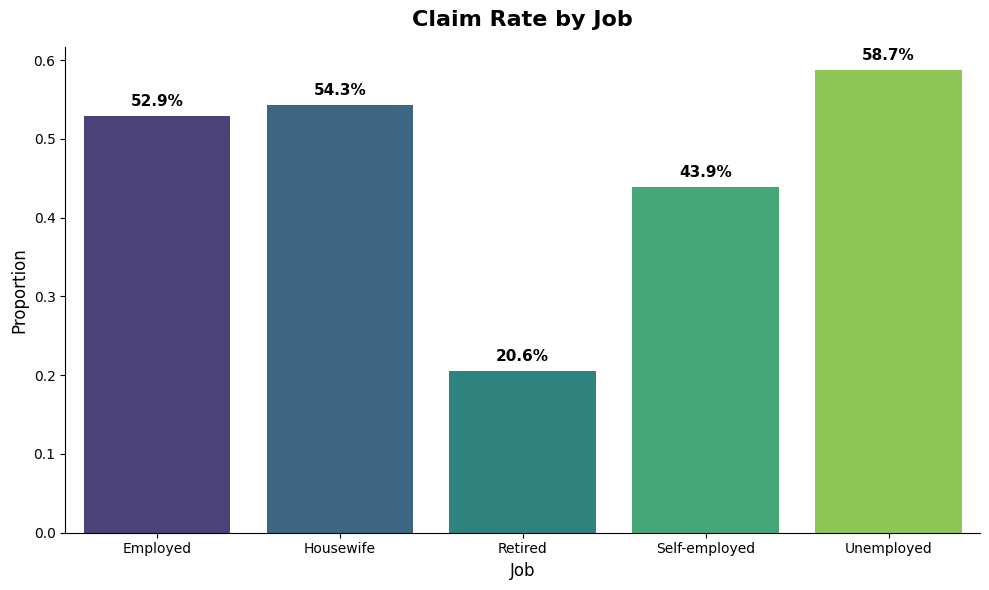

In [58]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.barplot(
    data=df_frequency,
    ax=ax,
    x="job",
    y="claimNumbMD",
    hue="job",
    legend=False,
    palette="viridis",
    order=["Employed", "Housewife", "Retired", "Self-employed", "Unemployed"],
    errorbar=None,
    dodge=False,
)

for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(
            f"{height * 100:.1f}%",
            (p.get_x() + p.get_width() / 2.0, height),
            ha="center",
            va="bottom",
            fontsize=11,
            fontweight="bold",
            xytext=(0, 5),
            textcoords="offset points",
        )

ax.set_title("Claim Rate by Job", fontweight="bold", fontsize=16, pad=15)
ax.set_xlabel("Job", fontsize=12)
ax.set_ylabel("Proportion", fontsize=12)

sns.despine()
fig.tight_layout()

In [59]:
contingency_job = pd.crosstab(df_frequency["job"], df_frequency["claimNumbMD"])

In [60]:
chi2_statistic, p_value, dof, expected = stats.chi2_contingency(contingency_job)

print(f"Chi-Square Statistic: {chi2_statistic:.2f}")
print(f"P-value: {p_value:.4e}")
print("Significant" if p_value < 0.05 else "Non-significant")

Chi-Square Statistic: 1045.83
P-value: 4.1672e-225
Significant


# Exploring `cover`

In [61]:
df_severity["cover"].value_counts()

cover
0    6794
1    5462
Name: count, dtype: int64

In [62]:
df_severity.groupby("cover")["claimSizeMD"].mean().round(2)

cover
0    956.27
1    754.09
Name: claimSizeMD, dtype: float64

In [63]:
df_severity.groupby("cover")["claimSizeMD"].median()

cover
0    614.0
1    502.0
Name: claimSizeMD, dtype: float64

In [64]:
claims_cover0 = df_severity[df_severity["cover"] == 0]["claimSizeMD"]
claims_cover1 = df_severity[df_severity["cover"] == 1]["claimSizeMD"]

In [65]:
u_statistic, p_value = stats.mannwhitneyu(claims_cover0, claims_cover1)

print(f"Mann-Whitney U statistic: {u_statistic:.2f}")
print(f"p-value: {p_value:.4f}")
print("Significant" if p_value < 0.05 else "Non-significant")

Mann-Whitney U statistic: 20435201.00
p-value: 0.0000
Significant


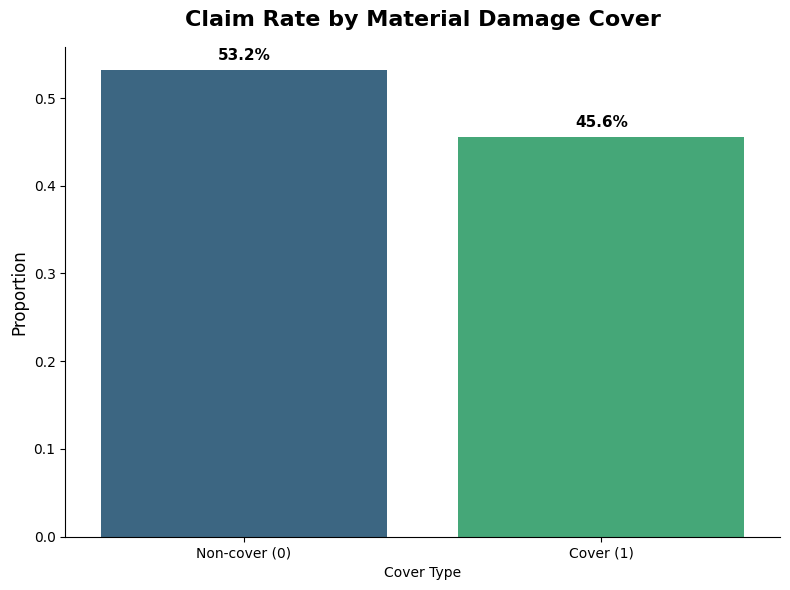

In [66]:
fig, ax = plt.subplots(figsize=(8, 6))

sns.barplot(
    data=df_frequency,
    ax=ax,
    x="cover",
    y="claimNumbMD",
    hue="cover",
    legend=False,
    palette="viridis",
    order=[0, 1],
    errorbar=None,
    dodge=False,
)

for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(
            f"{height * 100:.1f}%",
            (p.get_x() + p.get_width() / 2.0, height),
            ha="center",
            va="bottom",
            fontsize=11,
            fontweight="bold",
            xytext=(0, 5),
            textcoords="offset points",
        )

ax.set_xticks([0, 1])
ax.set_xticklabels(["Non-cover (0)", "Cover (1)"])

ax.set_title(
    "Claim Rate by Material Damage Cover", fontweight="bold", fontsize=16, pad=15
)
ax.set_xlabel("Cover Type")
ax.set_ylabel("Proportion", fontsize=12)

sns.despine()
fig.tight_layout()

In [67]:
contingency_cover = pd.crosstab(df_frequency["cover"], df_frequency["claimNumbMD"])

In [68]:
chi2_statistic, p_value, dof, expected = stats.chi2_contingency(contingency_cover)

print(f"Chi-Square Statistic: {chi2_statistic:.2f}")
print(f"P-value: {p_value:.4e}")
print("Significant" if p_value < 0.05 else "Non-significant")

Chi-Square Statistic: 141.25
P-value: 1.4175e-32
Significant


## Exploring Continuous variables

In [69]:
continuous_vars = ["age", "carVal", "density", "nYears"]
titles = [
    "Driver Age",
    "Car Value (€)",
    "Population Density (inh/km²)",
    "Policy Tenure (Years)",
]

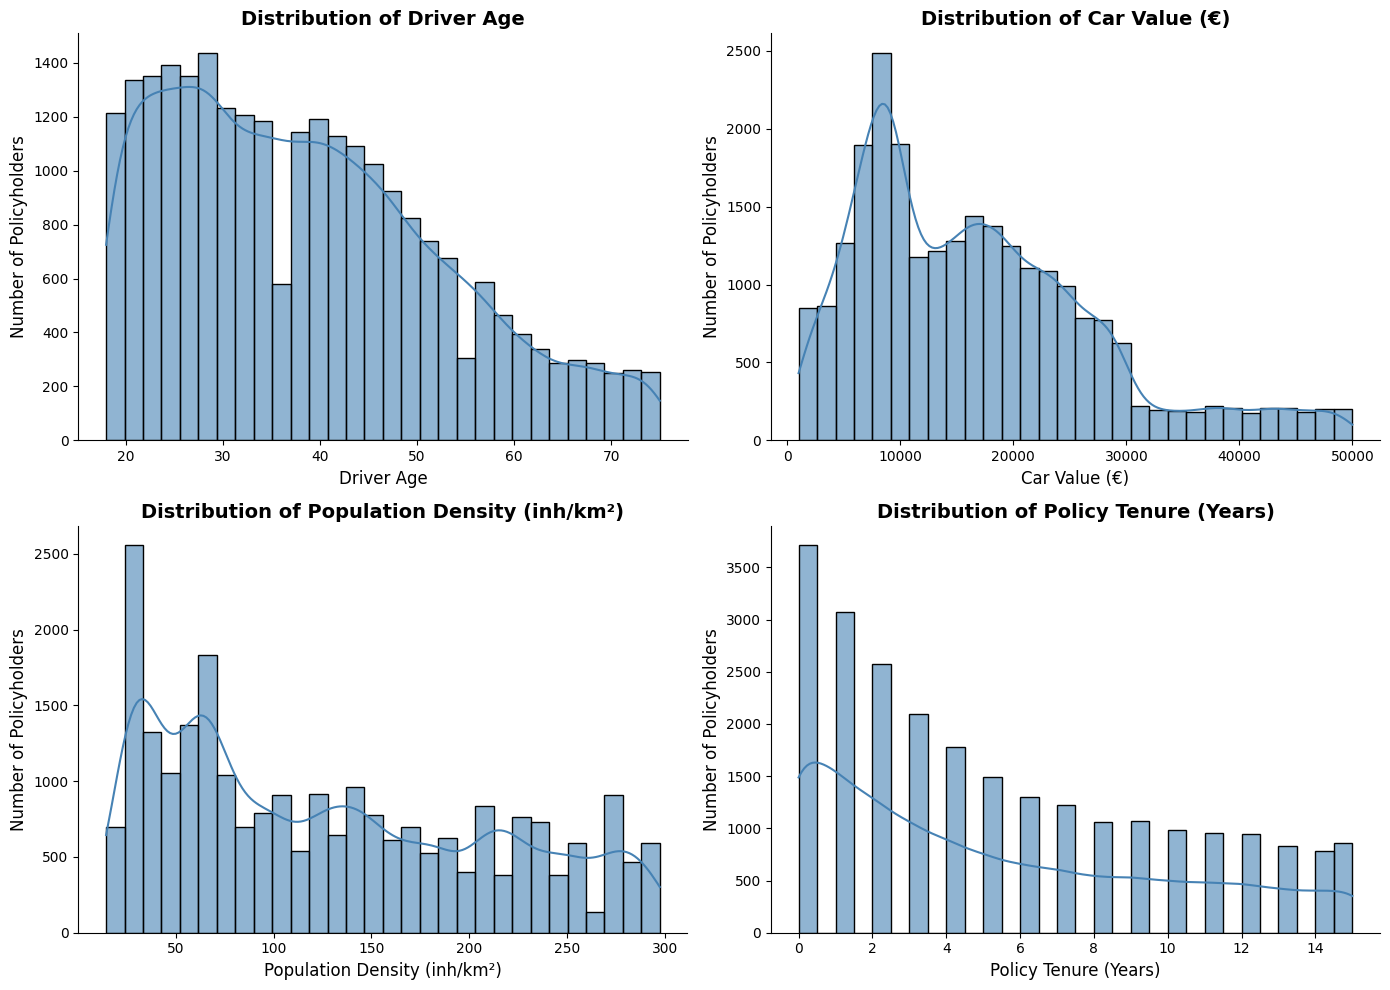

In [70]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, var in enumerate(continuous_vars):
    sns.histplot(
        data=df_frequency,
        x=var,
        ax=axes[i],
        kde=True,
        color="steelblue",
        bins=30,
        edgecolor="black",
        alpha=0.6,
    )

    axes[i].set_title(f"Distribution of {titles[i]}", fontweight="bold", fontsize=14)
    axes[i].set_xlabel(titles[i], fontsize=12)
    axes[i].set_ylabel("Number of Policyholders", fontsize=12)

sns.despine()
fig.tight_layout()

### `age`

In [71]:
corr_coef, p_val_sev = stats.spearmanr(df_severity["age"], df_severity["claimSizeMD"])

In [72]:
print(f"Spearman Correlation: {corr_coef:.4f}")
print(f"P-value: {p_val_sev:.4e}")
print("Significant correlation." if p_val_sev < 0.05 else "Non-significant.")

Spearman Correlation: -0.1490
P-value: 8.3956e-62
Significant correlation.


In [73]:
df_frequency["age_bucket"] = pd.qcut(df_frequency["age"], q=10)

In [74]:
df_severity["age_bucket"] = pd.qcut(df_severity["age"], q=10)

In [75]:
freq_trend = df_frequency.groupby("age_bucket")["claimNumbMD"].mean()
freq_trend

age_bucket
(17.999, 21.0]    0.723246
(21.0, 25.0]      0.668611
(25.0, 29.0]      0.613123
(29.0, 33.0]      0.505121
(33.0, 37.0]      0.441050
(37.0, 41.0]      0.441564
(41.0, 45.0]      0.448022
(45.0, 51.0]      0.395429
(51.0, 59.0]      0.365425
(59.0, 75.0]      0.289763
Name: claimNumbMD, dtype: float64

In [76]:
severity_trend = (
    df_severity.groupby("age_bucket")["claimSizeMD"].mean().round(decimals=2)
)
severity_trend

age_bucket
(17.999, 20.0]    1241.01
(20.0, 23.0]      1115.67
(23.0, 25.0]      1018.03
(25.0, 28.0]       867.03
(28.0, 32.0]       792.49
(32.0, 36.0]       719.25
(36.0, 41.0]       689.33
(41.0, 46.0]       689.75
(46.0, 54.0]       708.62
(54.0, 75.0]       766.03
Name: claimSizeMD, dtype: float64

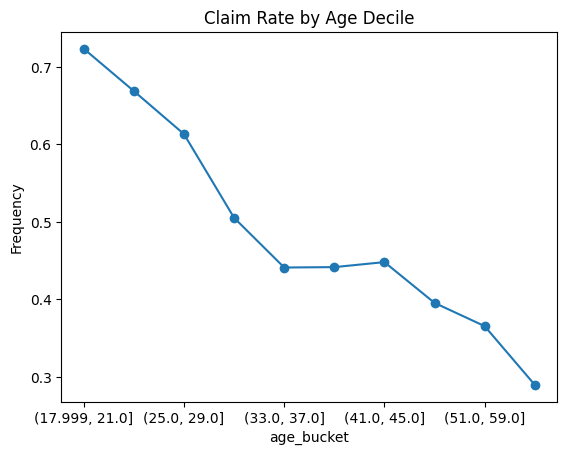

In [77]:
freq_trend.plot(kind="line", marker="o")
plt.title("Claim Rate by Age Decile")
plt.ylabel("Frequency")
plt.show()

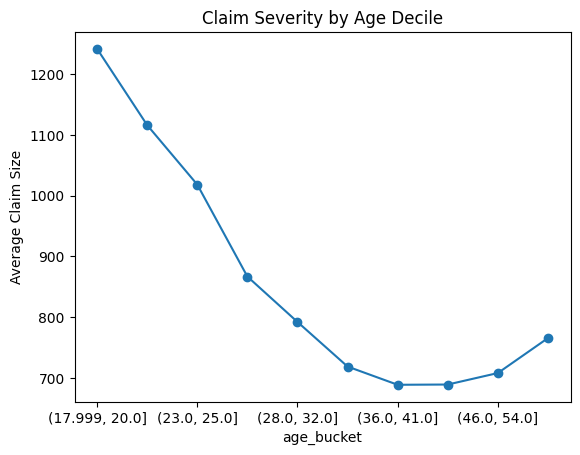

In [78]:
severity_trend.plot(kind="line", marker="o")
plt.title("Claim Severity by Age Decile")
plt.ylabel("Average Claim Size")
plt.show()

In [79]:
X = df_frequency[["age"]].values

In [80]:
inertia = []
silhouette_avg = []
range_n_clusters = range(2, 11)

In [81]:
for n_clusters in range_n_clusters:
    kmeans = KMeans(n_clusters=n_clusters, random_state=10, n_init="auto")
    cluster_labels = kmeans.fit_predict(X)

    inertia.append(kmeans.inertia_)
    silhouette_avg.append(silhouette_score(X, cluster_labels))

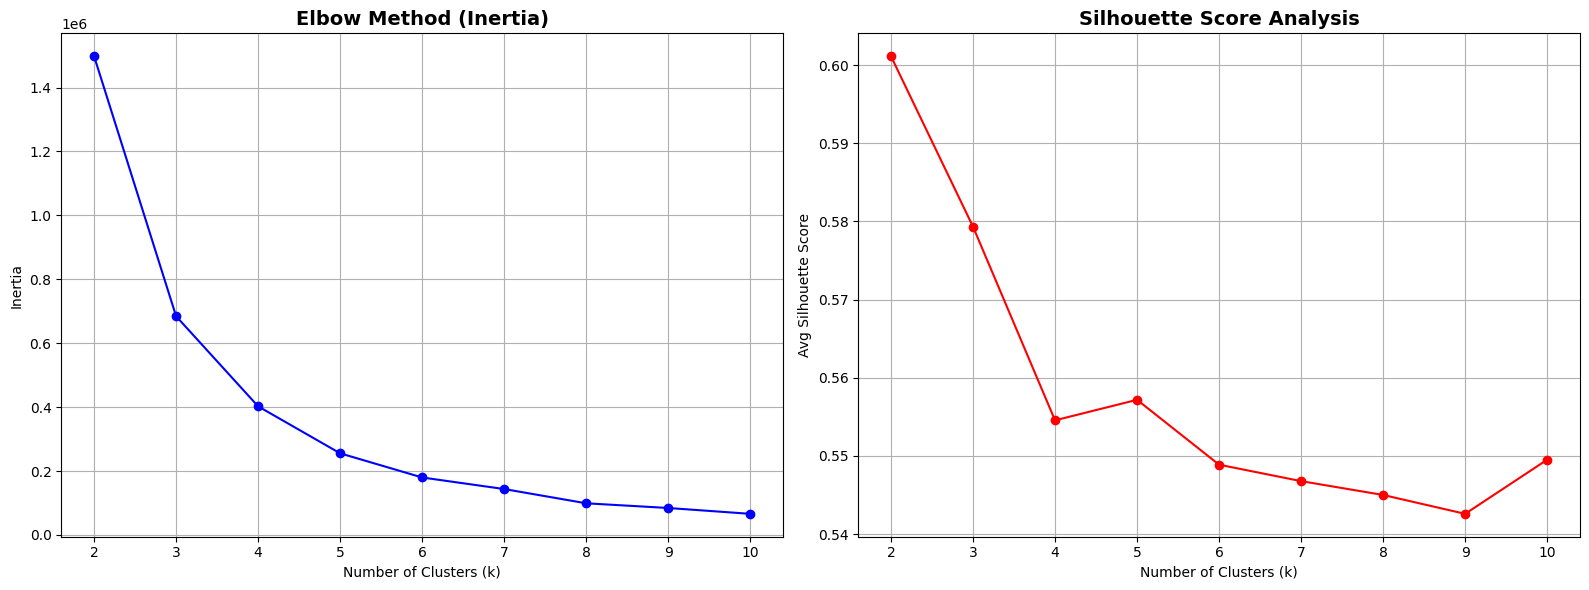

In [82]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

ax1.plot(range_n_clusters, inertia, marker="o", linestyle="-", color="b")
ax1.set_title("Elbow Method (Inertia)", fontweight="bold", fontsize=14)
ax1.set_xlabel("Number of Clusters (k)")
ax1.set_ylabel("Inertia")
ax1.grid(True)

ax2.plot(range_n_clusters, silhouette_avg, marker="o", linestyle="-", color="r")
ax2.set_title("Silhouette Score Analysis", fontweight="bold", fontsize=14)
ax2.set_xlabel("Number of Clusters (k)")
ax2.set_ylabel("Avg Silhouette Score")
ax2.grid(True)

fig.tight_layout()

In [83]:
OPTIMUM_AGE_NUM_CLUSTERS = 3

In [84]:
discretizer_age = KBinsDiscretizer(
    n_bins=OPTIMUM_AGE_NUM_CLUSTERS,
    encode="ordinal",
    strategy="kmeans",
    random_state=42,
)

In [85]:
df_frequency["age_cluster_code"] = discretizer_age.fit_transform(df_frequency[["age"]])
df_frequency["age_cluster_code"]

0        0.0
1        0.0
2        1.0
3        0.0
4        0.0
        ... 
24769    0.0
24770    0.0
24771    2.0
24772    0.0
24773    1.0
Name: age_cluster_code, Length: 24753, dtype: float64

In [86]:
edges = discretizer_age.bin_edges_[0]
edges

array([18.        , 35.02421959, 53.05114649, 75.        ])

In [87]:
age_labels = [f"{int(edges[i])} - {int(edges[i+1])}" for i in range(len(edges) - 1)]
age_labels

['18 - 35', '35 - 53', '53 - 75']

In [88]:
df_frequency["age_cluster"] = df_frequency["age_cluster_code"].map(
    lambda x: age_labels[int(x)]
)

In [89]:
df_frequency["age_cluster"].value_counts()

age_cluster
18 - 35    11708
35 - 53     8993
53 - 75     4052
Name: count, dtype: int64

In [90]:
contingency_age = pd.crosstab(df_frequency["age_cluster"], df_frequency["claimNumbMD"])

In [91]:
chi2_statistic, p_val, dof, expected = stats.chi2_contingency(contingency_age)

print(f"Chi-Square Statistic: {chi2_statistic:.2f}")
print(f"P-value: {p_val:.4e}")
print("Result: Significant" if p_val < 0.05 else "Result: Not Significant")

Chi-Square Statistic: 1325.65
P-value: 1.3776e-288
Result: Significant


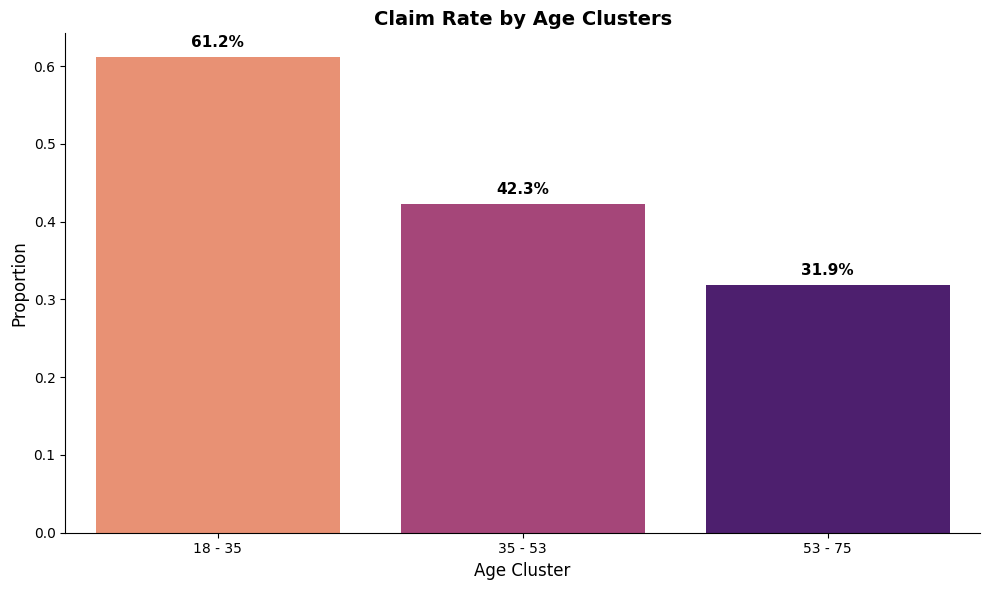

In [92]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.barplot(
    data=df_frequency,
    x="age_cluster",
    y="claimNumbMD",
    ax=ax,
    palette="magma_r",
    hue="age_cluster",
    legend=False,
    order=age_labels,
    errorbar=None,
    dodge=False,
)


for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(
            f"{height * 100:.1f}%",
            (p.get_x() + p.get_width() / 2.0, height),
            ha="center",
            va="bottom",
            fontsize=11,
            fontweight="bold",
            xytext=(0, 5),
            textcoords="offset points",
        )

ax.set_title("Claim Rate by Age Clusters", fontweight="bold", fontsize=14)
ax.set_xlabel("Age Cluster", fontsize=12)
ax.set_ylabel("Proportion", fontsize=12)

sns.despine()
fig.tight_layout()

In [93]:
df_severity["age_cluster_code"] = discretizer_age.transform(df_severity[["age"]])  # type: ignore
df_severity["age_cluster"] = df_severity["age_cluster_code"].map(
    lambda x: age_labels[int(x)]
)

### `carVal`

In [94]:
corr_coef, p_val_sev = stats.spearmanr(
    df_severity["carVal"], df_severity["claimSizeMD"]
)

In [95]:
print(f"Spearman Correlation: {corr_coef:.4f}")
print(f"P-value: {p_val_sev:.4e}")
print("Significant correlation" if p_val_sev < 0.05 else "Non-significant")

Spearman Correlation: -0.0177
P-value: 4.9600e-02
Significant correlation


but it's not a strong one

In [96]:
X_carVal = df_frequency[["carVal"]].values

In [97]:
k_range = range(2, 11)
inertia_val = []
silhouette_avg_val = []

In [98]:
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=7, n_init="auto")
    cluster_labels = kmeans.fit_predict(X_carVal).flatten()

    inertia_val.append(kmeans.inertia_)
    silhouette_avg_val.append(silhouette_score(X_carVal, cluster_labels))

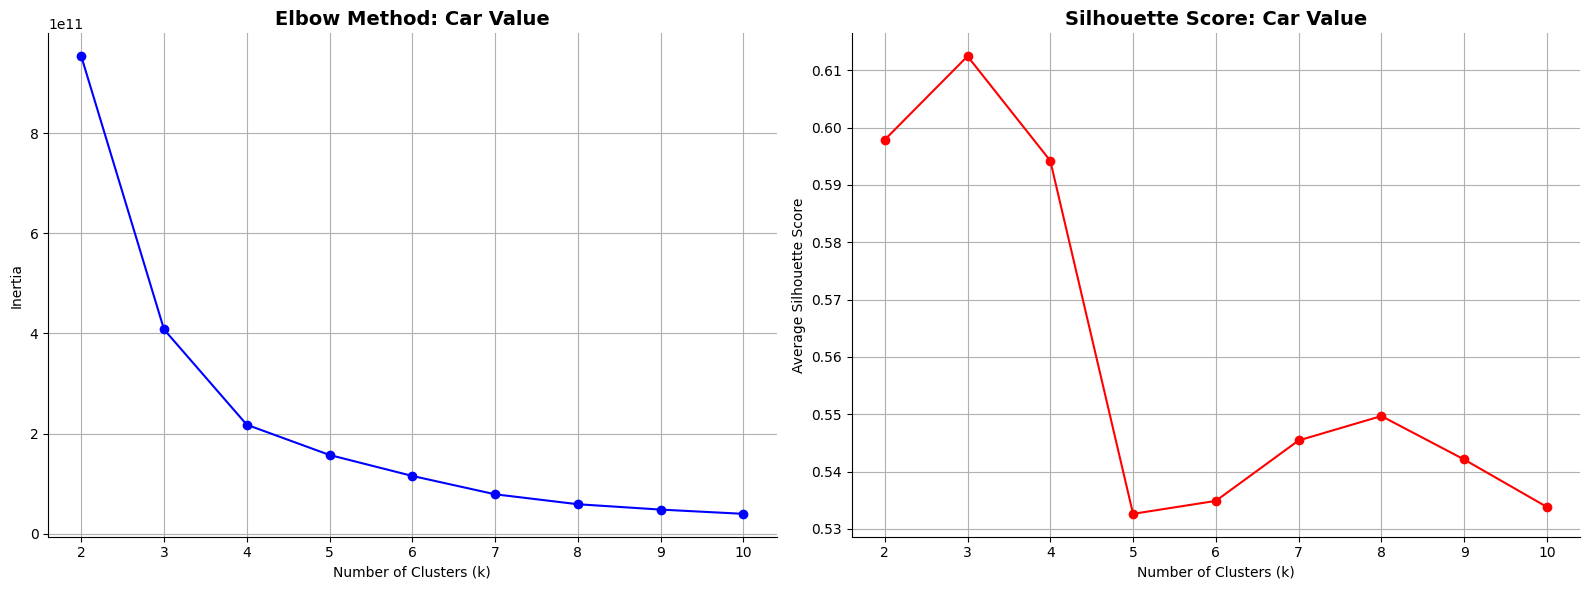

In [99]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

ax1.plot(list(k_range), inertia_val, marker="o", color="b")
ax1.set_title("Elbow Method: Car Value", fontweight="bold", fontsize=14)
ax1.set_xlabel("Number of Clusters (k)")
ax1.set_ylabel("Inertia")
ax1.grid(True)


ax2.plot(list(k_range), silhouette_avg_val, marker="o", color="r")
ax2.set_title("Silhouette Score: Car Value", fontweight="bold", fontsize=14)
ax2.set_xlabel("Number of Clusters (k)")
ax2.set_ylabel("Average Silhouette Score")
ax2.grid(True)

sns.despine()
fig.tight_layout()

In [100]:
OPTIMUM_CARVAL_NUM_CLUSTERS = 3

In [101]:
discretizer_carVal = KBinsDiscretizer(
    n_bins=3, encode="ordinal", strategy="kmeans", random_state=7
)

In [102]:
df_frequency["carVal_cluster_code"] = discretizer_carVal.fit_transform(
    df_frequency[["carVal"]]
)

In [103]:
carVal_edges = discretizer_carVal.bin_edges_[0]
carVal_edges

array([ 1000.        , 15076.1049061 , 31188.69208019, 49995.        ])

In [104]:
carVal_labels = [
    f"€{int(carVal_edges[i]):,} - €{int(carVal_edges[i+1]):,}"
    for i in range(len(carVal_edges) - 1)
]
carVal_labels

['€1,000 - €15,076', '€15,076 - €31,188', '€31,188 - €49,995']

In [105]:
df_frequency["carVal_cluster"] = df_frequency["carVal_cluster_code"].map(
    lambda x: carVal_labels[int(x)]
)
df_frequency["carVal_cluster"].value_counts()

carVal_cluster
€1,000 - €15,076     12401
€15,076 - €31,188    10083
€31,188 - €49,995     2269
Name: count, dtype: int64

In [106]:
contingency_carVal = pd.crosstab(
    df_frequency["carVal_cluster"], df_frequency["claimNumbMD"]
)

In [107]:
chi2_statistic, p_val, dof, expected = stats.chi2_contingency(contingency_carVal)

print(f"Chi-Square Statistic: {chi2_statistic:.2f}")
print(f"P-value: {p_val:.4e}")
if p_val < 0.05:
    print("Significant")
else:
    print("Non-Significant")

Chi-Square Statistic: 22.17
P-value: 1.5374e-05
Significant


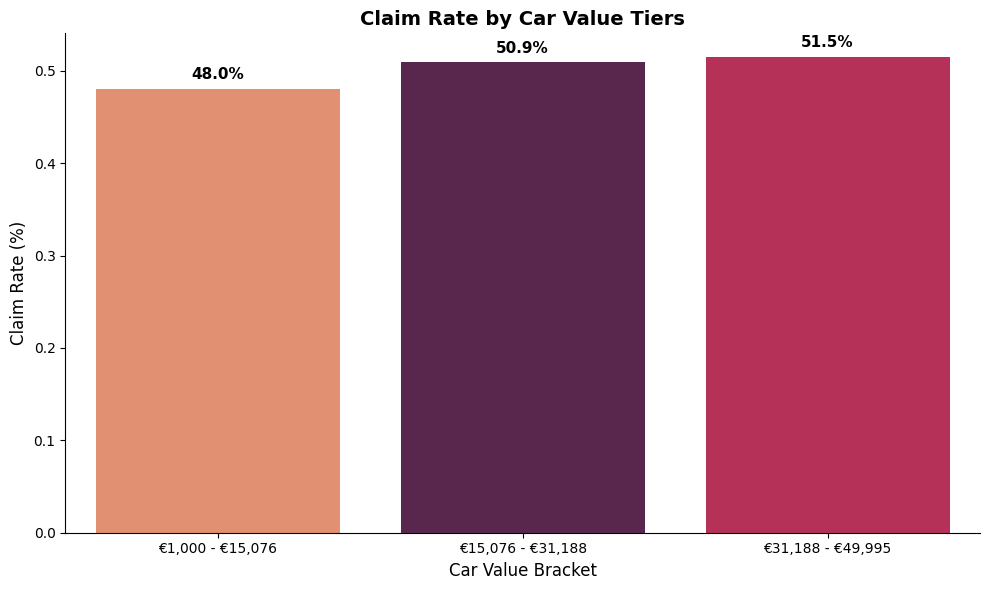

In [108]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(
    data=df_frequency,
    ax=ax,
    x="carVal_cluster",
    y="claimNumbMD",
    order=carVal_labels,
    palette="rocket",
    hue="carVal_cluster",
    legend=False,
    errorbar=None,
    dodge=False,
)


for p in ax.patches:
    h = p.get_height()
    if h > 0:
        plt.gca().annotate(
            f"{h*100:.1f}%",
            (p.get_x() + p.get_width() / 2.0, h),
            ha="center",
            va="bottom",
            fontweight="bold",
            fontsize=11,
            xytext=(0, 5),
            textcoords="offset points",
        )

ax.set_title("Claim Rate by Car Value Tiers", fontweight="bold", fontsize=14)
ax.set_ylabel("Claim Rate (%)", fontsize=12)
ax.set_xlabel("Car Value Bracket", fontsize=12)

sns.despine()
fig.tight_layout()

In [109]:
df_severity["carVal_cluster_code"] = discretizer_carVal.transform(df_severity[["carVal"]])  # type: ignore
df_severity["carVal_cluster"] = df_severity["carVal_cluster_code"].map(
    lambda x: carVal_labels[int(x)]
)

### `density`

In [110]:
corr_coef, p_val_sev = stats.spearmanr(
    df_severity["density"], df_severity["claimSizeMD"]
)

In [111]:
print(f"Spearman Correlation: {corr_coef:.4f}")
print(f"P-value: {p_val_sev:.4e}")
print("Significant correlation" if p_val_sev < 0.05 else "Non-significant")

Spearman Correlation: 0.1047
P-value: 3.2937e-31
Significant correlation


In [112]:
X_density = df_frequency[["density"]].values

In [113]:
k_range = range(2, 11)
inertia_density = []
silhouette_avg_density = []

In [114]:
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=15, n_init="auto")
    cluster_labels = kmeans.fit_predict(X_density)

    inertia_density.append(kmeans.inertia_)
    silhouette_avg_density.append(silhouette_score(X_density, cluster_labels))

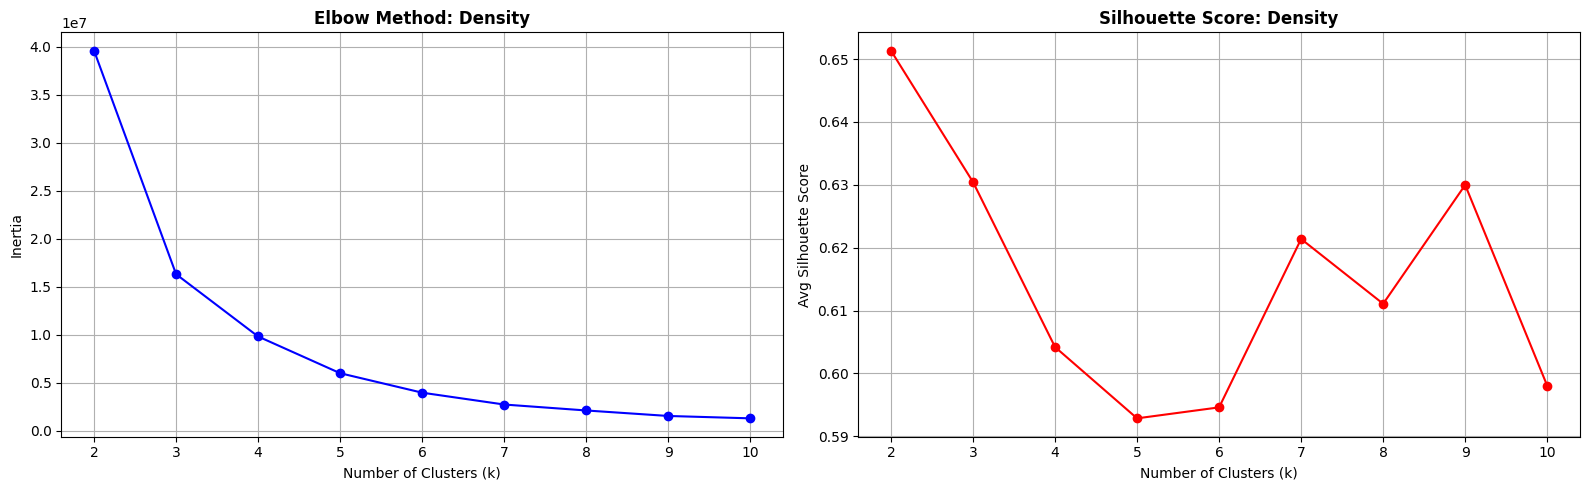

In [115]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

ax1.plot(list(k_range), inertia_density, marker="o", color="b")
ax1.set_title("Elbow Method: Density", fontweight="bold")
ax1.set_xlabel("Number of Clusters (k)")
ax1.set_ylabel("Inertia")
ax1.grid(True)

ax2.plot(list(k_range), silhouette_avg_density, marker="o", color="r")
ax2.set_title("Silhouette Score: Density", fontweight="bold")
ax2.set_xlabel("Number of Clusters (k)")
ax2.set_ylabel("Avg Silhouette Score")
ax2.grid(True)

fig.tight_layout()

In [116]:
OPTIMUM_DENSITY_NUM_CLUSTERS = 3

In [117]:
discretizer_density = KBinsDiscretizer(
    n_bins=OPTIMUM_DENSITY_NUM_CLUSTERS,
    encode="ordinal",
    strategy="kmeans",
    random_state=21,
)

In [118]:
df_frequency["density_cluster_code"] = discretizer_density.fit_transform(
    df_frequency[["density"]]
)

In [119]:
density_edges = discretizer_density.bin_edges_[0]
density_edges

array([ 14.37714238,  97.33566853, 193.94219961, 297.3851697 ])

In [120]:
density_labels = [
    f"{int(density_edges[i]):,} - {int(density_edges[i+1]):,} inh/km\u00b2"
    for i in range(len(density_edges) - 1)
]
density_labels

['14 - 97 inh/km²', '97 - 193 inh/km²', '193 - 297 inh/km²']

In [121]:
df_frequency["density_cluster"] = df_frequency["density_cluster_code"].map(
    lambda x: density_labels[int(x)]
)

In [122]:
df_frequency["density_cluster"].value_counts()

density_cluster
14 - 97 inh/km²      11248
97 - 193 inh/km²      7316
193 - 297 inh/km²     6189
Name: count, dtype: int64

In [123]:
contingency_density = pd.crosstab(
    df_frequency["density_cluster"], df_frequency["claimNumbMD"]
)
chi2_density, p_val_density, dof, expected = stats.chi2_contingency(contingency_density)

print(f"Chi-Square Statistic: {chi2_density:.2f}")
print(f"P-value: {p_val_density:.4e}")

if p_val_density < 0.05:
    print("Significant")
else:
    print("Not Significant")

Chi-Square Statistic: 520.77
P-value: 8.2406e-114
Significant


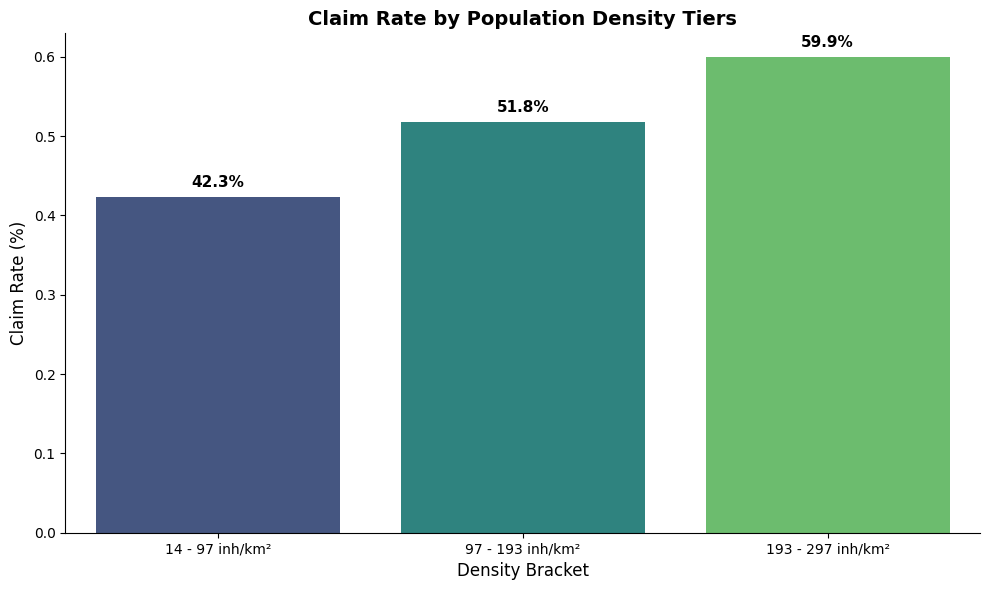

In [124]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.barplot(
    data=df_frequency,
    x="density_cluster",
    y="claimNumbMD",
    order=density_labels,
    palette="viridis",
    hue="density_cluster",
    legend=False,
    errorbar=None,
    dodge=False,
    ax=ax,
)

for p in ax.patches:
    h = p.get_height()
    if h > 0:
        ax.annotate(
            f"{h*100:.1f}%",
            (p.get_x() + p.get_width() / 2.0, h),
            ha="center",
            va="bottom",
            fontweight="bold",
            fontsize=11,
            xytext=(0, 5),
            textcoords="offset points",
        )

ax.set_title(
    f"Claim Rate by Population Density Tiers",
    fontweight="bold",
    fontsize=14,
)
ax.set_ylabel("Claim Rate (%)", fontsize=12)
ax.set_xlabel("Density Bracket", fontsize=12)


sns.despine(ax=ax)
fig.tight_layout()

In [125]:
df_severity["density_cluster_code"] = discretizer_density.transform(df_severity[["density"]])  # type: ignore
df_severity["density_cluster"] = df_severity["density_cluster_code"].map(
    lambda x: density_labels[int(x)]
)

### `nYears`

In [126]:
corr_coef, p_val_sev = stats.spearmanr(
    df_severity["nYears"], df_severity["claimSizeMD"]
)

In [127]:
print(f"Spearman Correlation: {corr_coef:.4f}")
print(f"P-value: {p_val_sev:.4e}")
print("Significant correlation" if p_val_sev < 0.05 else "Non-significant")

Spearman Correlation: -0.0228
P-value: 1.1467e-02
Significant correlation


but it's very close to zero. also it doesn't make sense to do clustering on `nYears` since this variable is basically discreet and ordinal

In [128]:
contingency_nYears = pd.crosstab(df_frequency["nYears"], df_frequency["claimNumbMD"])

In [129]:
chi2_nYears, p_val_nYears, dof, expected = stats.chi2_contingency(contingency_nYears)

print(f"Chi-Square Statistic: {chi2_nYears:.2f}")
print(f"P-value: {p_val_nYears:.4e}")

if p_val_nYears < 0.05:
    print("Significant")
else:
    print("Not Significant")

Chi-Square Statistic: 117.25
P-value: 6.4488e-18
Significant


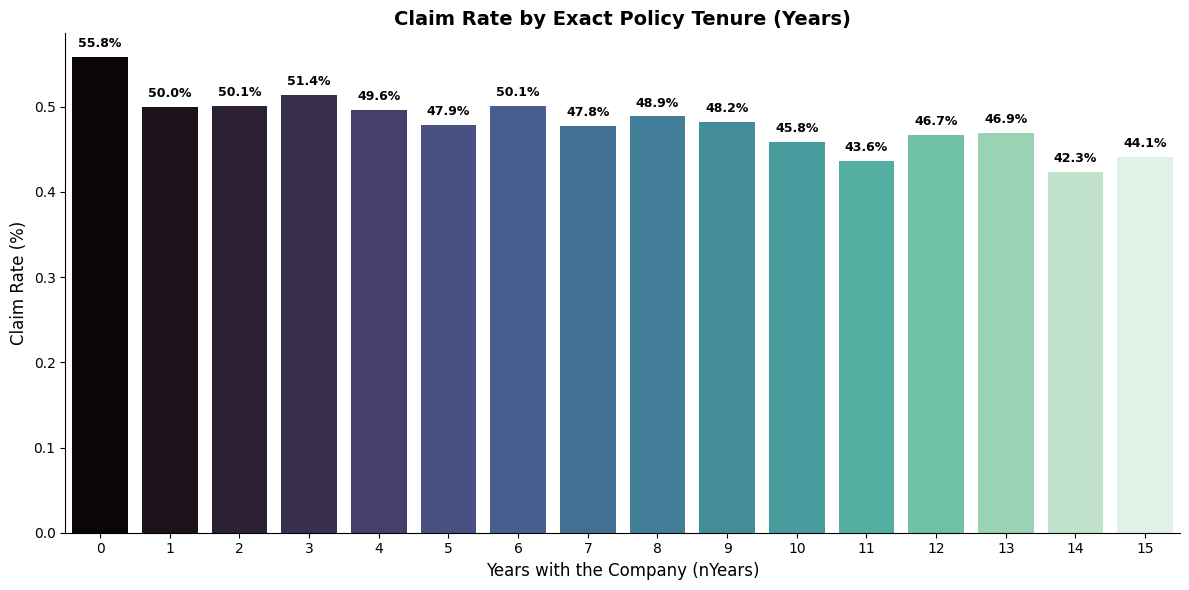

In [130]:
fig, ax = plt.subplots(figsize=(12, 6))

sns.barplot(
    data=df_frequency,
    ax=ax,
    x="nYears",
    y="claimNumbMD",
    hue="nYears",
    palette="mako",
    errorbar=None,
    dodge=False,
    legend=False,
)

for p in ax.patches:
    h = p.get_height()
    if h > 0:
        ax.annotate(
            f"{h*100:.1f}%",
            (p.get_x() + p.get_width() / 2.0, h),
            ha="center",
            va="bottom",
            fontweight="bold",
            fontsize=9,
            xytext=(0, 5),
            textcoords="offset points",
        )


ax.set_title(
    "Claim Rate by Exact Policy Tenure (Years)", fontweight="bold", fontsize=14
)
ax.set_ylabel("Claim Rate (%)", fontsize=12)
ax.set_xlabel("Years with the Company (nYears)", fontsize=12)

sns.despine(ax=ax)
fig.tight_layout()

## Correlation between the variables

In [131]:
covariates = [
    "gender",
    "carType",
    "carCat",
    "job",
    "cover",
    "age",
    "carVal",
    "density",
    "nYears",
]

In [132]:
df_corr_freq = df_frequency[covariates].copy()

In [133]:
for col in df_corr_freq.select_dtypes(include=["category", "str"]).columns:
    df_corr_freq[col] = df_corr_freq[col].astype("category").cat.codes

In [134]:
freq_corr_matrix = df_corr_freq.corr(method="spearman")

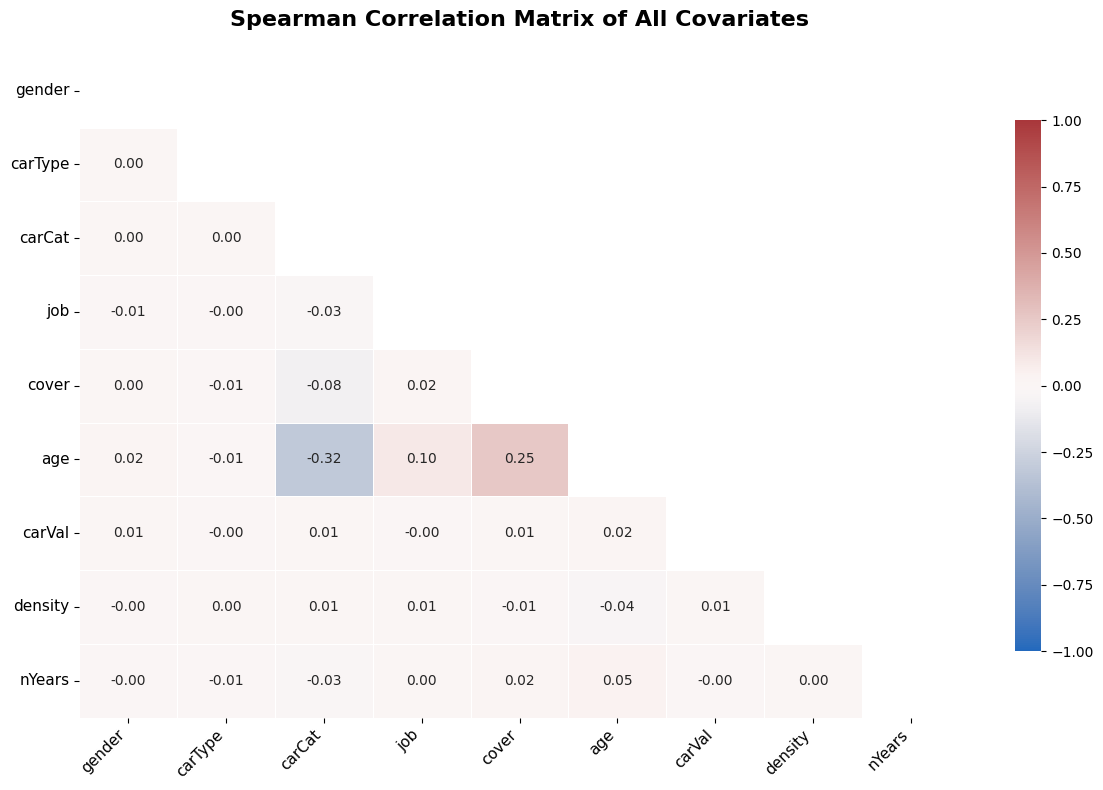

In [135]:
fig, ax = plt.subplots(figsize=(12, 8))

mask = np.triu(np.ones_like(freq_corr_matrix, dtype=bool))

sns.heatmap(
    freq_corr_matrix,
    mask=mask,
    cmap="vlag",
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    vmin=-1,
    vmax=1,
    cbar_kws={"shrink": 0.8},
    ax=ax,
)


ax.set_title(
    "Spearman Correlation Matrix of All Covariates",
    fontweight="bold",
    fontsize=16,
    pad=20,
)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", fontsize=11)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=11)

fig.tight_layout()

## Interaction Terms

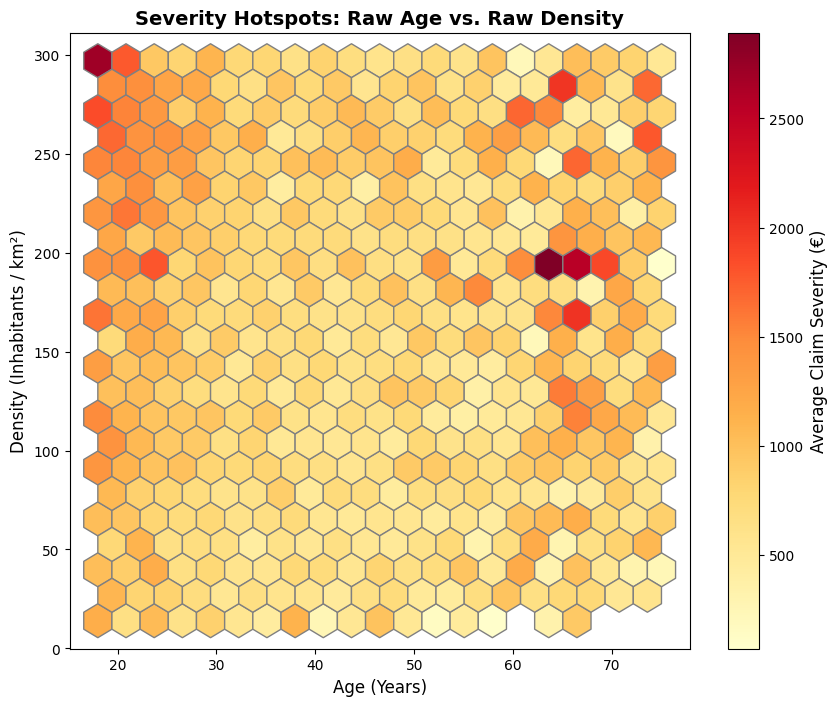

In [136]:
plt.figure(figsize=(10, 8))

hb = plt.hexbin(
    df_severity["age"],
    df_severity["density"],
    C=df_severity["claimSizeMD"],
    reduce_C_function=np.mean,
    gridsize=20,
    cmap="YlOrRd",
    edgecolors="grey",
    mincnt=1,
)


cb = plt.colorbar(hb)
cb.set_label("Average Claim Severity (€)", fontsize=12)

plt.title("Severity Hotspots: Raw Age vs. Raw Density", fontsize=14, fontweight="bold")
plt.xlabel("Age (Years)", fontsize=12)
plt.ylabel("Density (Inhabitants / km²)", fontsize=12)
plt.grid(False)
plt.show()

## Saving the Results

In [137]:
df_frequency.to_csv("data/frequency2.csv", index=False)

In [138]:
df_severity.to_csv("data/severity2.csv", index=False)